In [3]:
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download("jasonairroi/airbnb-market-data-europe")

print(os.listdir(path))

my_data = pd.read_csv(
    os.path.join(path, "listings.csv"),
    on_bad_lines='skip'
)

print(my_data.head())
print(my_data.isnull().sum())

# Question 1: Which city has the highest average Airbnb price?

# Question 2: Do higher-rated listings cost more?

# Question 3: How does distance from the city center affect price?

Using Colab cache for faster access to the 'airbnb-market-data-europe' dataset.
['listings.csv', 'listings.parquet', 'past_rates.csv', 'past_rates.parquet']


/tmp/ipykernel_54391/564509121.py:9: DtypeWarning: Columns (4,7,8,9,10,11,12,17,51,52,53,54,55,56,57) have mixed types. Specify dtype option on import or set low_memory=False.
  my_data = pd.read_csv(


  listing_id  listing_type    room_type  \
0     121902   Entire home  entire_home   
1     805342  Entire condo  entire_home   
2     805361   Entire home  entire_home   
3     853827  Entire villa  entire_home   
4     967193  Entire villa  entire_home   

                                     cover_photo_url photos_count  \
0  https://a0.muscache.com/im/pictures/77c0e3a9-0...           77   
1  https://a0.muscache.com/im/pictures/11494599/4...           16   
2  https://a0.muscache.com/im/pictures/bda48dbc-d...           34   
3  https://a0.muscache.com/im/pictures/26626113/a...           70   
4  https://a0.muscache.com/im/pictures/68107669/2...           37   

        host_id superhost latitude longitude guests  ... l90d_revpar_native  \
0  fe453949b595     false  37.0758   27.2426      6  ...                0.0   
1  59711ec4c245     false  37.0092   27.2563      3  ...                0.0   
2  d217bf6e3427     false  37.0292   27.4410      5  ...                0.0   
3  605fc7d

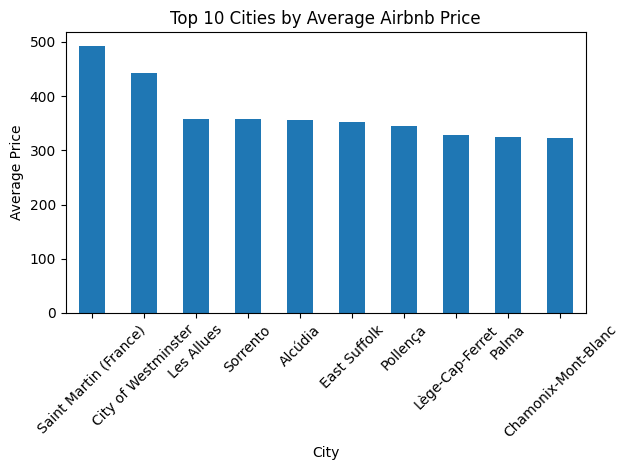

In [4]:
import matplotlib.pyplot as plt

city_price = my_data.groupby("city")["ttm_avg_rate"].mean().sort_values(ascending=False).head(10)

plt.figure()
city_price.plot(kind="bar")
plt.title("Top 10 Cities by Average Airbnb Price")
plt.xlabel("City")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("graph1.png")
plt.show()

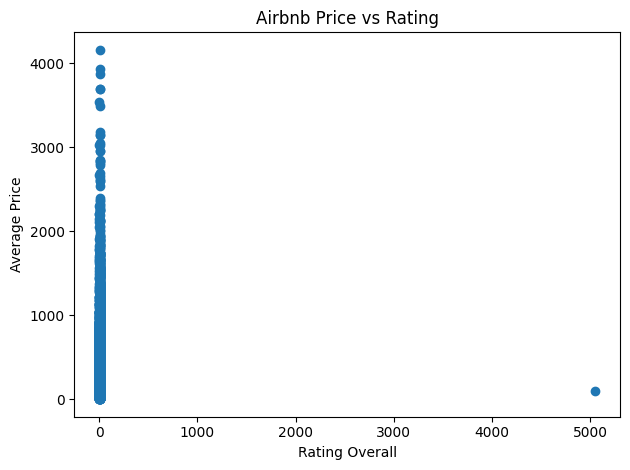

In [6]:
plt.figure()
plt.scatter(my_data["rating_overall"], my_data["ttm_avg_rate"])
plt.title("Airbnb Price vs Rating")
plt.xlabel("Rating Overall")
plt.ylabel("Average Price")
plt.tight_layout()

plt.savefig("graph2.png")
plt.show()

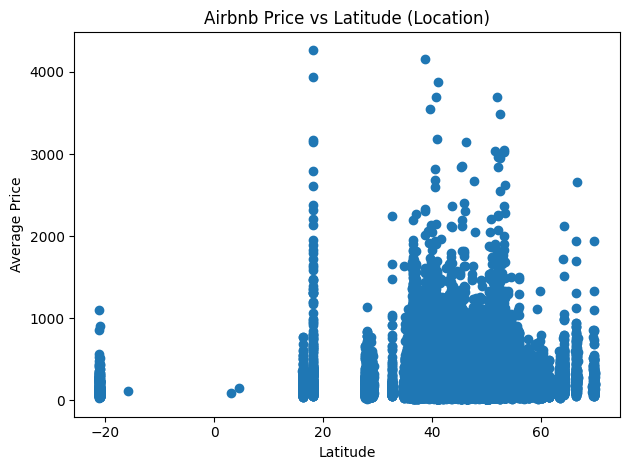

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Force numeric conversion (VERY important for Kaggle datasets)
temp = my_data[["latitude", "ttm_avg_rate"]].copy()

temp["latitude"] = pd.to_numeric(temp["latitude"], errors="coerce")
temp["ttm_avg_rate"] = pd.to_numeric(temp["ttm_avg_rate"], errors="coerce")

# Drop broken rows
temp = temp.dropna()

plt.figure()
plt.scatter(temp["latitude"], temp["ttm_avg_rate"])
plt.title("Airbnb Price vs Latitude (Location)")
plt.xlabel("Latitude")
plt.ylabel("Average Price")
plt.tight_layout()

plt.savefig("graph3.png")
plt.show()

In [7]:
import os
print(os.listdir())

['.config', 'graph2.png', 'graph3.png', 'graph1.png', 'sample_data']
